回调函数示例：
使用普通函数: 100
使用lambda函数: 100

Files already downloaded and verified


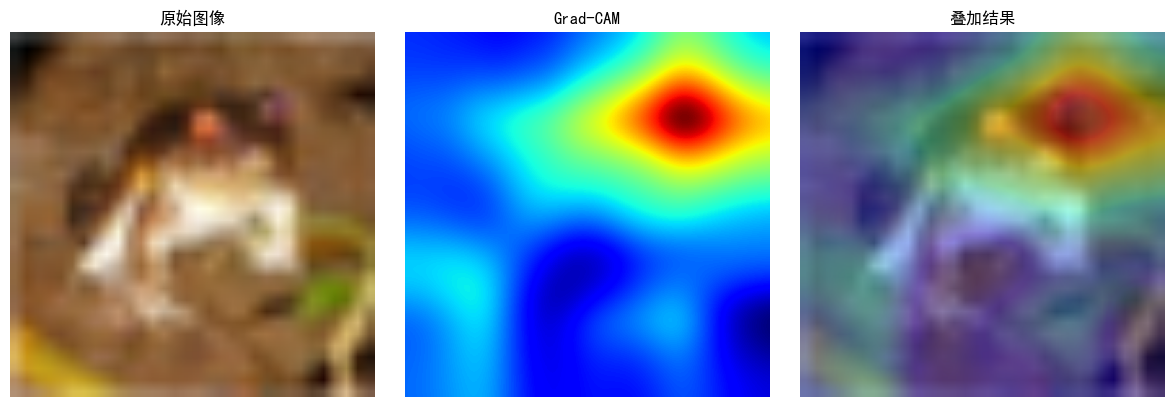

In [1]:
"""
Day 42: Grad-CAM与Hook函数

本节主要内容：
1. 回调函数(Callback)和lambda函数
   - 回调函数是作为参数传递给其他函数的函数
   - lambda函数是一种简单的匿名函数，用于创建一次性的简单函数

2. hook函数（钩子函数）
   - 在深度学习中，hook函数用于"钩住"模型的某些层，获取或修改中间结果
   - 分为forward hook（前向钩子）和backward hook（后向钩子）
   - forward hook可以获取层的输入和输出
   - backward hook可以获取层的梯度信息

3. Grad-CAM（Gradient-weighted Class Activation Mapping）
   - 一种可视化CNN模型决策的技术
   - 使用梯度信息来理解模型关注的图像区域
   - 通过生成热力图来展示模型的注意力焦点
"""

import torch  # PyTorch深度学习框架
import torch.nn as nn  # 神经网络模块
import torch.nn.functional as F  # 函数式接口
import torchvision  # 计算机视觉工具包
from torchvision.models import ResNet18_Weights  # ResNet18预训练权重
import torchvision.transforms as transforms  # 图像变换工具
import matplotlib.pyplot as plt  # 绘图库
import numpy as np  # 数值计算库
from PIL import Image  # 图像处理库

# 设置matplotlib中文字体，避免中文显示乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，确保结果可复现
torch.manual_seed(42)
# 检测是否可以使用GPU，如果可以就使用GPU，否则使用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GradCAM:
    """
    Grad-CAM（Gradient-weighted Class Activation Mapping）实现类
    
    工作原理：
    1. 获取CNN模型中指定层的特征图（通过forward hook）
    2. 获取特征图对于目标类别的梯度（通过backward hook）
    3. 计算每个通道的重要性权重
    4. 生成类激活图（CAM）来显示模型关注的区域
    
    使用方法：
    1. 创建GradCAM实例，指定模型和目标层
    2. 调用generate_cam方法生成类激活图
    3. 使用完毕后调用remove_hooks清理钩子
    """
    def __init__(self, model, target_layer):
        """
        初始化GradCAM
        
        参数：
        - model: 预训练的CNN模型
        - target_layer: 要可视化的目标层（通常是最后的卷积层）
        """
        self.model = model
        self.target_layer = target_layer
        self.gradients = None  # 存储梯度
        self.features = None   # 存储特征图
        
        # 注册钩子列表，用于后续移除
        self.hooks = []
        self._register_hooks()
    
    def _register_hooks(self):
        """
        注册前向和后向钩子函数
        
        钩子函数的作用：
        1. forward_hook: 保存前向传播时的特征图
        2. backward_hook: 保存反向传播时的梯度信息
        """
        def forward_hook(module, input, output):
            """前向钩子函数，保存特征图"""
            self.features = output.detach()  # detach()创建不需要梯度的副本
        
        def backward_hook(module, grad_input, grad_output):
            """后向钩子函数，保存梯度"""
            self.gradients = grad_output[0].detach()
        
        # 注册钩子
        # register_forward_hook在前向传播时触发
        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        # register_full_backward_hook在反向传播时触发，支持多个自动求导节点
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))
    
    def remove_hooks(self):
        """
        移除所有注册的钩子
        在使用完GradCAM后必须调用此方法，否则可能造成内存泄漏
        """
        for hook in self.hooks:
            hook.remove()
    
    def generate_cam(self, input_image, target_class=None):
        """
        生成类激活图（CAM）
        
        参数：
        - input_image: 输入图像张量，形状为[1, C, H, W]
        - target_class: 目标类别索引，如果为None则使用模型预测的类别
        
        返回：
        - cam: 类激活图（numpy数组）
        
        工作流程：
        1. 前向传播得到预测结果
        2. 计算目标类别的梯度
        3. 计算特征图的权重
        4. 生成并归一化类激活图
        """
        # 前向传播
        model_output = self.model(input_image)
        
        # 如果没有指定目标类别，使用预测的类别
        if target_class is None:
            target_class = torch.argmax(model_output, 1).item()
        
        # 反向传播
        self.model.zero_grad()  # 清除现有梯度
        model_output[0, target_class].backward()  # 计算目标类别的梯度
        
        # 计算每个通道的权重（全局平均池化）
        weights = torch.mean(self.gradients, dim=(2, 3))[0, :]
        
        # 生成CAM
        # 创建与特征图大小相同的零张量
        cam = torch.zeros(self.features.shape[2:], dtype=torch.float32).to(device)
        # 将每个通道的特征图与其权重相乘并相加
        for i, w in enumerate(weights):
            cam += w * self.features[0, i, :, :]
        
        cam = F.relu(cam)  # 使用ReLU确保只关注正面贡献
        cam = cam - torch.min(cam)  # 减去最小值
        cam = cam / torch.max(cam)  # 归一化到[0,1]范围
        
        return cam.cpu().numpy()

def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    反归一化图像张量
    
    在训练深度学习模型时，我们通常会对输入图像进行标准化（减均值除以标准差）
    显示图像时需要将其转换回原始范围
    
    参数：
    - tensor: 输入张量
    - mean: ImageNet数据集的均值
    - std: ImageNet数据集的标准差
    
    返回：
    - 反归一化后的张量，像素值在[0,1]范围内
    """
    tensor = tensor.clone()  # 创建副本避免修改原始数据
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)  # 反归一化：x = x * std + mean
    return tensor.clamp_(0, 1)  # 将值限制在[0,1]范围内

def visualize_cam(image, cam):
    """
    可视化原始图像和CAM
    
    创建三个子图：
    1. 原始图像
    2. Grad-CAM热力图
    3. 热力图与原始图像的叠加结果
    
    参数：
    - image: 输入图像张量
    - cam: 类激活图（numpy数组）
    """
    plt.figure(figsize=(12, 4))
    
    # 处理原始图像
    img = denormalize(image)  # 反归一化
    img_np = img.permute(1, 2, 0).cpu().numpy()  # 调整通道顺序并转换为numpy数组
    h, w = img_np.shape[:2]  # 获取图像尺寸
    
    # 调整CAM大小以匹配原始图像
    cam_resized = np.float32(cam)
    cam_resized = Image.fromarray(cam_resized)
    cam_resized = cam_resized.resize((w, h), Image.LANCZOS)  # LANCZOS提供高质量的重采样
    cam_resized = np.array(cam_resized)
    
    # 显示原始图像
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title('原始图像')
    plt.axis('off')
    
    # 显示热力图
    plt.subplot(1, 3, 2)
    plt.imshow(cam_resized, cmap='jet')  # 使用jet颜色映射
    plt.title('Grad-CAM')
    plt.axis('off')
    
    # 显示叠加图
    plt.subplot(1, 3, 3)
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]  # 转换为RGB热力图
    overlayed = 0.6 * img_np + 0.4 * heatmap  # 将热力图叠加到原始图像上
    overlayed = np.clip(overlayed, 0, 1)  # 确保值在[0,1]范围内
    plt.imshow(overlayed)
    plt.title('叠加结果')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def main():
    """
    主程序：演示Grad-CAM的使用
    
    步骤：
    1. 加载预训练的ResNet18模型
    2. 准备输入图像
    3. 创建GradCAM实例
    4. 生成并可视化类激活图
    """
    # 加载预训练模型，使用新的weights参数（替代已弃用的pretrained参数）
    weights = ResNet18_Weights.DEFAULT
    model = torchvision.models.resnet18(weights=weights).to(device)
    model.eval()  # 设置为评估模式

    # 准备图像转换
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # 调整图像大小
        transforms.ToTensor(),          # 转换为张量
        transforms.Normalize(           # 标准化
            mean=[0.485, 0.456, 0.406],  # ImageNet数据集的均值
            std=[0.229, 0.224, 0.225]    # ImageNet数据集的标准差
        )
    ])

    # 加载示例图像（使用CIFAR-10数据集的第一张图片）
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
    image, _ = trainset[0]
    image = transform(image).unsqueeze(0).to(device)  # 添加batch维度并移到设备

    # 创建Grad-CAM（使用最后一个残差块的输出）
    grad_cam = GradCAM(model, model.layer4[-1])

    try:
        # 生成CAM
        cam = grad_cam.generate_cam(image)

        # 可视化结果
        visualize_cam(image[0], cam)
    finally:
        # 确保钩子被清理（即使发生异常）
        grad_cam.remove_hooks()

if __name__ == '__main__':
    """
    回调函数和lambda函数示例
    
    回调函数：
    - 是一种将函数作为参数传递给另一个函数的编程模式
    - 允许在特定事件发生时执行自定义代码
    
    lambda函数：
    - 也称为匿名函数
    - 用于创建简单的一次性函数
    - 语法：lambda 参数: 表达式
    """
    def process_data(data, callback):
        """回调函数示例"""
        result = data * 2
        return callback(result)

    # 使用普通函数作为回调
    def square(x):
        return x ** 2

    # 使用lambda函数作为回调（等价于上面的square函数）
    result1 = process_data(5, square)  # 使用命名函数
    result2 = process_data(5, lambda x: x ** 2)  # 使用lambda函数

    print("回调函数示例：")
    print(f"使用普通函数: {result1}")
    print(f"使用lambda函数: {result2}")
    print()

    # 运行主程序
    main()